# Tag 02 - Data Preprocessing / Datenvorverarbeitung

This notebook solves the Day 2 preprocessing exercises.

## Main topics
1. Robust Scaling and Skewness Correction
2. Scaling for Linear Models vs Tree-Based Models
3. Polynomial Features and Scaling
4. Encoding High-Cardinality Categorical Features

The notebook is self-contained and does not need external CSV files.
Outputs are saved into:

`Tag_02_Datenvorverarbeitung/output/`

In [1]:
from pathlib import Path
import warnings

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_wine, load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler, StandardScaler, MinMaxScaler, OneHotEncoder, PolynomialFeatures
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, mean_squared_error, r2_score
from sklearn.feature_extraction import FeatureHasher

In [2]:
# Project paths

BASE_DIR = Path.cwd()

# If notebook is run from exercise folder, go one level up
if BASE_DIR.name in ["exercise", "notebooks"]:
    BASE_DIR = BASE_DIR.parent

OUTPUT_DIR = BASE_DIR / "output"
DATA_DIR = BASE_DIR / "data"

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
DATA_DIR.mkdir(exist_ok=True)

print("Base folder:", BASE_DIR)
print("Output folder:", OUTPUT_DIR)

Base folder: C:\Users\esmae\Documents\Educx Kurs machine lerning\ML_Projekt_Workspace\02-advanced-data-preprocessing
Output folder: C:\Users\esmae\Documents\Educx Kurs machine lerning\ML_Projekt_Workspace\02-advanced-data-preprocessing\output


In [3]:
# Helper functions

def save_plot(filename):
    path = OUTPUT_DIR / filename
    plt.tight_layout()
    plt.savefig(path, dpi=150)
    plt.show()
    print("Saved:", path)

def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

# Exercise 1 - Robust Scaling and Skewness Correction

Goal:
- Load a numerical dataset
- Check skewness
- Apply `log1p` transformation to highly skewed positive features
- Apply `RobustScaler`
- Compare distributions before and after preprocessing

Why this matters:
- Skewed data can distort model learning
- Outliers can dominate scaling
- RobustScaler uses median and IQR, so it is less sensitive to outliers

In [4]:
# Built-in dataset, no internet needed
wine = load_wine()
df_wine = pd.DataFrame(wine.data, columns=wine.feature_names)

print("Shape:", df_wine.shape)
display(df_wine.head())

Shape: (178, 13)


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0


In [5]:
# Check skewness

skewness_before = df_wine.skew().sort_values(ascending=False)
display(skewness_before)

skewed_features = skewness_before[abs(skewness_before) > 1].index.tolist()
print("Skewed features with abs(skewness) > 1:")
print(skewed_features)

magnesium                       1.098191
malic_acid                      1.039651
color_intensity                 0.868585
proline                         0.767822
proanthocyanins                 0.517137
nonflavanoid_phenols            0.450151
alcalinity_of_ash               0.213047
total_phenols                   0.086639
flavanoids                      0.025344
hue                             0.021091
alcohol                        -0.051482
ash                            -0.176699
od280/od315_of_diluted_wines   -0.307285
dtype: float64

Skewed features with abs(skewness) > 1:
['magnesium', 'malic_acid']


In [6]:
# Apply log1p only to positive skewed features with non-negative values

df_wine_corrected = df_wine.copy()

for feature in skewed_features:
    if df_wine_corrected[feature].min() >= 0:
        df_wine_corrected[feature] = np.log1p(df_wine_corrected[feature])

skewness_after_log = df_wine_corrected.skew().sort_values(ascending=False)

comparison_skewness = pd.DataFrame({
    "Before": skewness_before,
    "After_log1p": skewness_after_log
})

display(comparison_skewness)

comparison_skewness.to_csv(OUTPUT_DIR / "day02_ex1_skewness_before_after.csv")

,Before,After_log1p
alcalinity_of_ash,0.213047,0.213047
alcohol,-0.051482,-0.051482
ash,-0.176699,-0.176699
color_intensity,0.868585,0.868585
flavanoids,0.025344,0.025344
hue,0.021091,0.021091
magnesium,1.098191,0.605723
malic_acid,1.039651,0.529222
nonflavanoid_phenols,0.450151,0.450151
od280/od315_of_diluted_wines,-0.307285,-0.307285


In [7]:
# Robust scaling

robust_scaler = RobustScaler()
wine_scaled = pd.DataFrame(
    robust_scaler.fit_transform(df_wine_corrected),
    columns=df_wine_corrected.columns
)

display(wine_scaled.head())
wine_scaled.to_csv(OUTPUT_DIR / "day02_ex1_wine_robust_scaled.csv", index=False)

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,0.897338,-0.123538,0.201439,-0.906977,1.327738,0.420804,0.553892,-0.358209,1.050000,0.318792,0.222222,0.924949,0.808050
1,0.114068,-0.066893,-0.633094,-1.930233,0.103365,0.278960,0.374251,-0.477612,-0.392857,-0.104027,0.251852,0.503043,0.777090
2,0.083650,0.353999,0.892086,-0.209302,0.154283,0.420804,0.661677,-0.238806,1.792857,0.332215,0.192593,0.316430,1.055728
3,1.003802,0.064944,0.402878,-0.627907,0.729108,1.413712,0.811377,-0.597015,0.892857,1.043624,-0.311111,0.543611,1.664603
4,0.144487,0.501066,1.467626,0.348837,0.950948,0.420804,0.332335,0.298507,0.378571,-0.124161,0.222222,0.121704,0.126935


Selected features for visualization: ['magnesium', 'malic_acid']


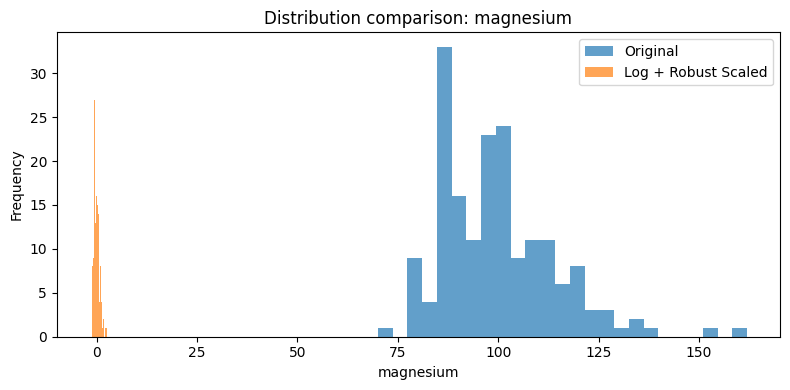

Saved: C:\Users\esmae\Documents\Educx Kurs machine lerning\ML_Projekt_Workspace\02-advanced-data-preprocessing\output\day02_ex1_hist_magnesium.png


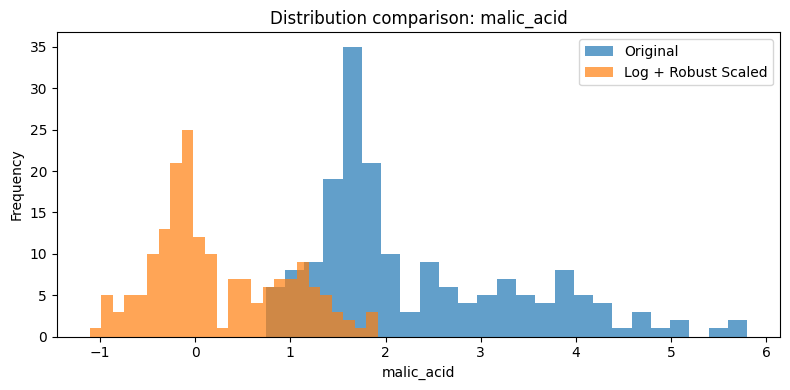

Saved: C:\Users\esmae\Documents\Educx Kurs machine lerning\ML_Projekt_Workspace\02-advanced-data-preprocessing\output\day02_ex1_hist_malic_acid.png


In [8]:
# Compare original vs corrected/scaled for selected features

selected_features = skewed_features[:4]

if len(selected_features) == 0:
    selected_features = df_wine.columns[:4].tolist()

print("Selected features for visualization:", selected_features)

for feature in selected_features:
    plt.figure(figsize=(8, 4))
    plt.hist(df_wine[feature], bins=25, alpha=0.7, label="Original")
    plt.hist(wine_scaled[feature], bins=25, alpha=0.7, label="Log + Robust Scaled")
    plt.title(f"Distribution comparison: {feature}")
    plt.xlabel(feature)
    plt.ylabel("Frequency")
    plt.legend()
    save_plot(f"day02_ex1_hist_{feature}.png")

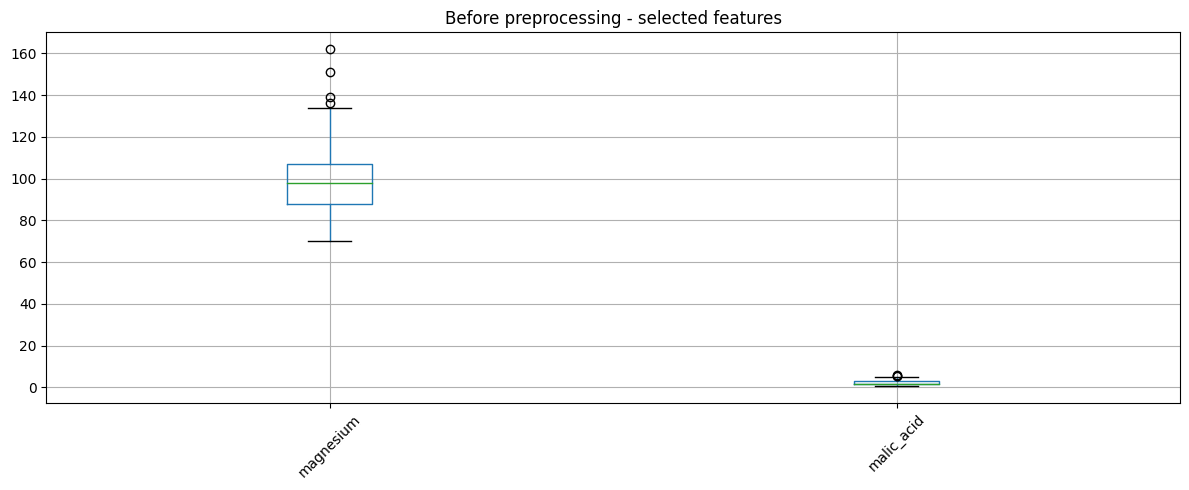

Saved: C:\Users\esmae\Documents\Educx Kurs machine lerning\ML_Projekt_Workspace\02-advanced-data-preprocessing\output\day02_ex1_boxplot_before.png


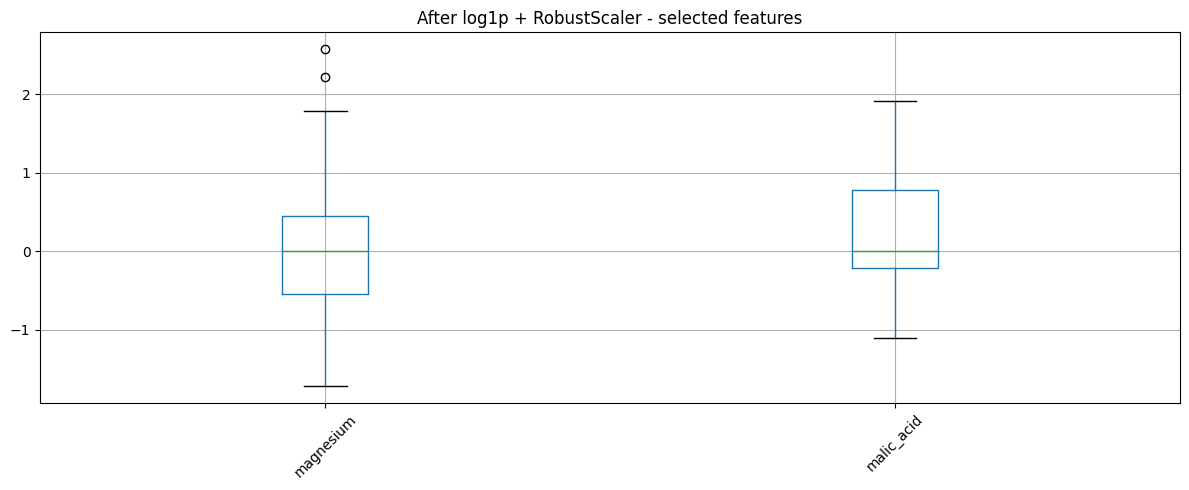

Saved: C:\Users\esmae\Documents\Educx Kurs machine lerning\ML_Projekt_Workspace\02-advanced-data-preprocessing\output\day02_ex1_boxplot_after.png


In [9]:
plt.figure(figsize=(12, 5))
df_wine[selected_features].boxplot(rot=45)
plt.title("Before preprocessing - selected features")
save_plot("day02_ex1_boxplot_before.png")

plt.figure(figsize=(12, 5))
wine_scaled[selected_features].boxplot(rot=45)
plt.title("After log1p + RobustScaler - selected features")
save_plot("day02_ex1_boxplot_after.png")

# Exercise 2 - Scaling for Linear Models vs Tree-Based Models

Goal:
- Use a dataset with numerical and categorical features
- Apply StandardScaler to numerical features
- Apply OneHotEncoder to categorical features
- Train Logistic Regression and Random Forest
- Compare performance

Important idea:
- Linear models are sensitive to scaling
- Tree-based models usually do not need feature scaling in the same way

In [10]:
# Titanic-like small dataset, self-contained

df_titanic = pd.DataFrame({
    "age": [22, 38, 26, 35, 35, 54, 2, 27, 14, 4, 58, 20, 39, 55, 31, 18, 45, 29, 34, 41],
    "fare": [7.25, 71.28, 7.92, 53.10, 8.05, 51.86, 21.08, 11.13, 30.07, 16.70, 26.55, 8.05, 31.28, 27.72, 13.00, 7.75, 83.47, 10.50, 26.00, 15.50],
    "sex": ["male", "female", "female", "female", "male", "male", "male", "male", "female", "female", "female", "male", "female", "male", "female", "female", "male", "male", "female", "male"],
    "embarked": ["S", "C", "S", "S", "S", "S", "S", "S", "C", "S", "S", "S", "C", "S", "S", "Q", "C", "S", "S", "Q"],
    "class": ["Third", "First", "Third", "First", "Third", "First", "Third", "Third", "Second", "Third", "First", "Third", "First", "First", "Second", "Third", "First", "Third", "Second", "Third"],
    "survived": [0, 1, 1, 1, 0, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 0, 0, 1, 0]
})

display(df_titanic.head())

,age,fare,sex,embarked,class,survived
0,22,7.25,male,S,Third,0
1,38,71.28,female,C,First,1
2,26,7.92,female,S,Third,1
3,35,53.10,female,S,First,1
4,35,8.05,male,S,Third,0


In [11]:
X = df_titanic.drop(columns=["survived"])
y = df_titanic["survived"]

numeric_features = ["age", "fare"]
categorical_features = ["sex", "embarked", "class"]

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

In [12]:
# Logistic Regression pipeline

logreg_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=1000))
])

logreg_pipeline.fit(X_train, y_train)
y_pred_logreg = logreg_pipeline.predict(X_test)

logreg_acc = accuracy_score(y_test, y_pred_logreg)
print("Logistic Regression Accuracy:", logreg_acc)

Logistic Regression Accuracy: 0.8333333333333334


In [13]:
# Random Forest pipeline

rf_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(random_state=42))
])

rf_pipeline.fit(X_train, y_train)
y_pred_rf = rf_pipeline.predict(X_test)

rf_acc = accuracy_score(y_test, y_pred_rf)
print("Random Forest Accuracy:", rf_acc)

Random Forest Accuracy: 1.0


,Model,Accuracy
0,Logistic Regression,0.833333
1,Random Forest,1.000000


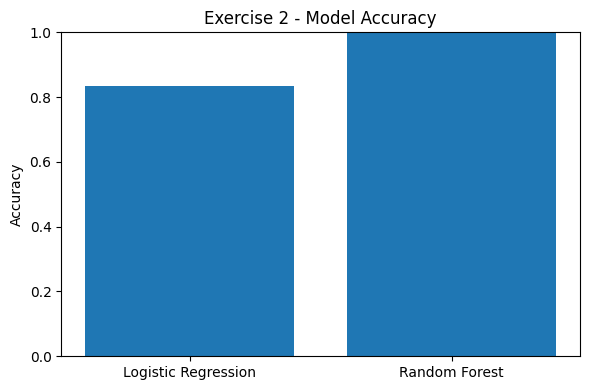

Saved: C:\Users\esmae\Documents\Educx Kurs machine lerning\ML_Projekt_Workspace\02-advanced-data-preprocessing\output\day02_ex2_model_accuracy.png


In [14]:
model_comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "Accuracy": [logreg_acc, rf_acc]
})

display(model_comparison)

model_comparison.to_csv(OUTPUT_DIR / "day02_ex2_model_comparison.csv", index=False)

plt.figure(figsize=(6, 4))
plt.bar(model_comparison["Model"], model_comparison["Accuracy"])
plt.title("Exercise 2 - Model Accuracy")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
save_plot("day02_ex2_model_accuracy.png")

# Exercise 3 - Feature Scaling and Polynomial Features

Goal:
- Use a regression dataset
- Compare different preprocessing orders:
  1. No scaling + polynomial features
  2. Scaling before polynomial features
  3. Polynomial features before scaling
- Train Ridge Regression
- Compare RMSE and R2

Important idea:
Polynomial features can create very large values.
Scaling helps Ridge Regression handle these features better.

In [15]:
# Built-in regression dataset, no internet needed

diabetes = load_diabetes()
X_diabetes = pd.DataFrame(diabetes.data, columns=diabetes.feature_names)
y_diabetes = diabetes.target

display(X_diabetes.head())

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641


In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X_diabetes, y_diabetes, test_size=0.30, random_state=42
)

results_poly = []

In [17]:
# Case 1: Polynomial features without scaling

poly = PolynomialFeatures(degree=3, include_bias=False)

X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

ridge = Ridge(alpha=1.0)
ridge.fit(X_train_poly, y_train)

y_pred = ridge.predict(X_test_poly)

results_poly.append({
    "Method": "Polynomial only - no scaling",
    "RMSE": rmse(y_test, y_pred),
    "R2": r2_score(y_test, y_pred)
})

In [18]:
# Case 2: Scaling before polynomial features

pipeline_scale_before = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("poly", PolynomialFeatures(degree=3, include_bias=False)),
    ("model", Ridge(alpha=1.0))
])

pipeline_scale_before.fit(X_train, y_train)
y_pred = pipeline_scale_before.predict(X_test)

results_poly.append({
    "Method": "StandardScaler before PolynomialFeatures",
    "RMSE": rmse(y_test, y_pred),
    "R2": r2_score(y_test, y_pred)
})

In [19]:
# Case 3: Polynomial features before scaling

pipeline_scale_after = Pipeline(steps=[
    ("poly", PolynomialFeatures(degree=3, include_bias=False)),
    ("scaler", StandardScaler()),
    ("model", Ridge(alpha=1.0))
])

pipeline_scale_after.fit(X_train, y_train)
y_pred = pipeline_scale_after.predict(X_test)

results_poly.append({
    "Method": "PolynomialFeatures before StandardScaler",
    "RMSE": rmse(y_test, y_pred),
    "R2": r2_score(y_test, y_pred)
})

,Method,RMSE,R2
0,Polynomial only - no scaling,55.778726,0.423659
2,PolynomialFeatures before StandardScaler,83.926052,-0.304776
1,StandardScaler before PolynomialFeatures,92.760273,-0.593920


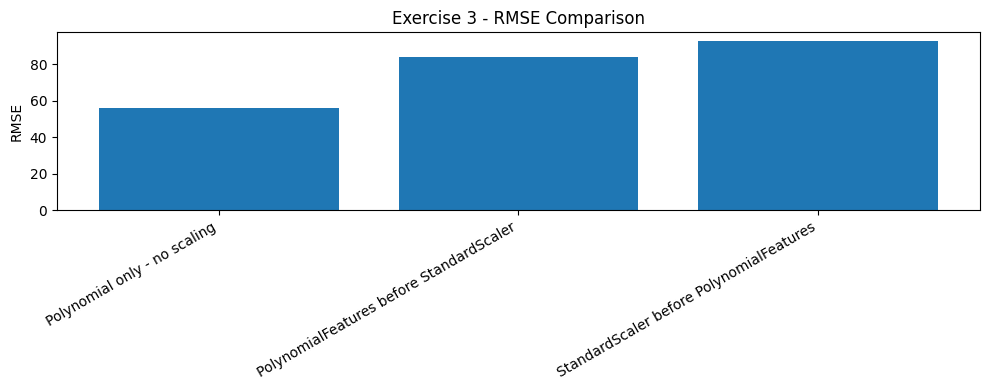

Saved: C:\Users\esmae\Documents\Educx Kurs machine lerning\ML_Projekt_Workspace\02-advanced-data-preprocessing\output\day02_ex3_rmse_comparison.png


In [20]:
poly_results_df = pd.DataFrame(results_poly).sort_values("RMSE")
display(poly_results_df)

poly_results_df.to_csv(OUTPUT_DIR / "day02_ex3_polynomial_scaling_results.csv", index=False)

plt.figure(figsize=(10, 4))
plt.bar(poly_results_df["Method"], poly_results_df["RMSE"])
plt.title("Exercise 3 - RMSE Comparison")
plt.ylabel("RMSE")
plt.xticks(rotation=30, ha="right")
save_plot("day02_ex3_rmse_comparison.png")

# Exercise 4 - Encoding High-Cardinality Categorical Features

Goal:
- Work with categorical features with many possible values
- Apply:
  1. Hashing Encoding
  2. Frequency Encoding
  3. Mean Target Encoding

Important idea:
One-Hot-Encoding can create too many columns if a categorical feature has many unique values.
For high-cardinality features, alternative encodings are useful.

In [21]:
df_customers = pd.DataFrame({
    "user_id": ["A1", "A2", "A3", "A1", "A2", "A3", "A4", "A5", "A6", "A7", "A8", "A9", "A10", "A11", "A12"],
    "city": ["New York", "Los Angeles", "San Francisco", "New York", "Los Angeles", "San Diego",
             "San Diego", "San Jose", "San Francisco", "Berlin", "Hamburg", "Munich", "Cologne", "Bonn", "Frankfurt"],
    "purchase": [100, 200, 150, 300, 400, 500, 100, 200, 250, 180, 220, 350, 120, 160, 410],
    "target": [0, 1, 1, 0, 1, 0, 1, 1, 0, 1, 0, 1, 0, 0, 1]
})

display(df_customers)

,user_id,city,purchase,target
0,A1,New York,100,0
1,A2,Los Angeles,200,1
2,A3,San Francisco,150,1
3,A1,New York,300,0
4,A2,Los Angeles,400,1
5,A3,San Diego,500,0
6,A4,San Diego,100,1
7,A5,San Jose,200,1
8,A6,San Francisco,250,0
9,A7,Berlin,180,1


In [22]:
# Frequency Encoding

df_encoded = df_customers.copy()

city_frequency = df_encoded["city"].value_counts()
df_encoded["city_frequency"] = df_encoded["city"].map(city_frequency)

user_frequency = df_encoded["user_id"].value_counts()
df_encoded["user_frequency"] = df_encoded["user_id"].map(user_frequency)

display(df_encoded[["city", "city_frequency", "user_id", "user_frequency"]])

,city,city_frequency,user_id,user_frequency
0,New York,2,A1,2
1,Los Angeles,2,A2,2
2,San Francisco,2,A3,2
3,New York,2,A1,2
4,Los Angeles,2,A2,2
5,San Diego,2,A3,2
6,San Diego,2,A4,1
7,San Jose,1,A5,1
8,San Francisco,2,A6,1
9,Berlin,1,A7,1


In [23]:
# Mean Target Encoding

city_mean_target = df_encoded.groupby("city")["target"].mean()
df_encoded["city_mean_target"] = df_encoded["city"].map(city_mean_target)

user_mean_target = df_encoded.groupby("user_id")["target"].mean()
df_encoded["user_mean_target"] = df_encoded["user_id"].map(user_mean_target)

display(df_encoded[["city", "city_mean_target", "user_id", "user_mean_target"]])

,city,city_mean_target,user_id,user_mean_target
0,New York,0.0,A1,0.0
1,Los Angeles,1.0,A2,1.0
2,San Francisco,0.5,A3,0.5
3,New York,0.0,A1,0.0
4,Los Angeles,1.0,A2,1.0
5,San Diego,0.5,A3,0.5
6,San Diego,0.5,A4,1.0
7,San Jose,1.0,A5,1.0
8,San Francisco,0.5,A6,0.0
9,Berlin,1.0,A7,1.0


In [24]:
# Hashing Encoding using FeatureHasher

hasher = FeatureHasher(n_features=5, input_type="string")

hashed_city = hasher.transform(df_encoded["city"])
hashed_city_df = pd.DataFrame(
    hashed_city.toarray(),
    columns=[f"city_hash_{i}" for i in range(5)]
)

display(hashed_city_df.head())

ValueError: Samples can not be a single string. The input must be an iterable over iterables of strings.

In [25]:
final_encoded = pd.concat(
    [
        df_encoded.reset_index(drop=True),
        hashed_city_df.reset_index(drop=True)
    ],
    axis=1
)

display(final_encoded)

final_encoded.to_csv(OUTPUT_DIR / "day02_ex4_high_cardinality_encoding.csv", index=False)

NameError: name 'hashed_city_df' is not defined

# Day 2 Summary

Key points:

- Preprocessing prepares raw data for machine learning.
- Skewness can be detected with `.skew()`.
- `log1p` can reduce strong positive skew.
- `RobustScaler` is useful when outliers are present.
- Numerical features can be scaled with StandardScaler or MinMaxScaler.
- Categorical features must be encoded before modeling.
- One-Hot-Encoding is useful for low-cardinality categories.
- Hashing, Frequency Encoding and Mean Target Encoding can help with high-cardinality features.
- Train/Test Split is needed to evaluate the model on unseen data.